In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("C:/Users/User/Desktop/Навчання/Стажування/raw_waste_data_2015_2024.csv")

In [3]:
df.head()

,Показник,Територіальний розріз,Джерело утворення чи переробки відходів,Клас небезпеки відходів,Категорія розрізу,Розріз,Періодичність,Період,Значення cпостереження,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,Примітки часового ряду,Примітки спостереження
0,Обсяг утворених відходів від економічної діяль...,Запорізька,"Підприємства, що здійснюють утворення та оброб...",IV. Не небезпечні відходи,Загалом,Загалом,Річна,2022,1364.5,Тонна,Тисячі,Один,NaN,За 2014-2021 роки дані наведено без урахування...,"До 2022 року - Підприємства, що здійснюють утв...",NaN
1,Обсяг утворених відходів від економічної діяль...,Запорізька,"Підприємства, що здійснюють утворення та оброб...",IV. Не небезпечні відходи,Загалом,Загалом,Річна,2024,909.5,Тонна,Тисячі,Один,NaN,За 2014-2021 роки дані наведено без урахування...,"До 2022 року - Підприємства, що здійснюють утв...",NaN
2,Обсяг утворених відходів від економічної діяль...,Київська,"Підприємства, що здійснюють утворення та оброб...",I-IV. Відходи в цілому,Загалом,Загалом,Річна,2022,470.1,Тонна,Тисячі,Один,NaN,За 2014-2021 роки дані наведено без урахування...,"До 2022 року - Підприємства, що здійснюють утв...",NaN
3,Обсяг утворених відходів від економічної діяль...,Київська,"Підприємства, що здійснюють утворення та оброб...",I-IV. Відходи в цілому,Загалом,Загалом,Річна,2024,856.5,Тонна,Тисячі,Один,NaN,За 2014-2021 роки дані наведено без урахування...,"До 2022 року - Підприємства, що здійснюють утв...",NaN
4,Обсяг утворених відходів від економічної діяль...,Дніпропетровська,"Підприємства, що здійснюють утворення та оброб...",I-IV. Відходи в цілому,Загалом,Загалом,Річна,2022,114082.8,Тонна,Тисячі,Один,NaN,За 2014-2021 роки дані наведено без урахування...,"До 2022 року - Підприємства, що здійснюють утв...",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23810 entries, 0 to 23809
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Показник                                 23810 non-null  object 
 1   Територіальний розріз                    23810 non-null  object 
 2   Джерело утворення чи переробки відходів  23810 non-null  object 
 3   Клас небезпеки відходів                  23810 non-null  object 
 4   Категорія розрізу                        23810 non-null  object 
 5   Розріз                                   23810 non-null  object 
 6   Періодичність                            23810 non-null  object 
 7   Період                                   23810 non-null  int64  
 8   Значення cпостереження                   15684 non-null  float64
 9   Одиниця виміру                           23810 non-null  object 
 10  Масштабування                            23810

In [5]:
missing = df['Значення cпостереження'].isnull().sum()
print(f"Пропущених значень у показниках: {missing} ({missing / len(df):.1%})")
print("Years min/max:", df['Період'].min(), df['Період'].max())

Пропущених значень у показниках: 8126 (34.1%)
Years min/max: 2015 2024


In [6]:
df = df[df['Період'] >= 2019].copy()

In [7]:
df_filtered = df[
    (df['Територіальний розріз'] == 'Україна') &
    (df['Клас небезпеки відходів'] == 'I-IV. Відходи в цілому') &
    (df['Розріз'] == 'Усього')]
df_filtered.shape

(46, 16)

In [8]:
df_pivot = df_filtered.pivot(
    index="Показник",
    columns="Період",
    values="Значення cпостереження")

df_pivot

Період,2019,2020,2021,2022,2023,2024
Показник,,,,,,
Обсяг видалених відходів на полігони,238997.2,275985.3,288606.9,101887.1,108209.1,142001.4
Обсяг відновлених відходів,108024.1,100524.6,107622.0,59144.2,43542.4,29583.4
"Обсяг відходів, накопичених протягом експлуатації у спеціально відведених місцях та об'єктах",15398649.4,15635259.6,NaN,NaN,NaN,NaN
"Обсяг відходів, переданих іншим суб’єктам господарювання",21959.5,13980.1,NaN,12536.9,13524.1,12362.0
Обсяг експортованих відходів,260.6,257.8,NaN,20.2,27.5,38.2
Обсяг наявних відходів на кінець року,94402.3,125792.0,NaN,380212.8,3597.2,3916.5
Обсяг спалених відходів,1059.0,1008.0,989.5,803.4,959.5,937.2
Обсяг утворених відходів,441516.5,462373.5,493271.1,204358.5,183196.8,238338.6
Обсяг імпортованих відходів,22.0,2.7,NaN,14.8,2.6,231.4


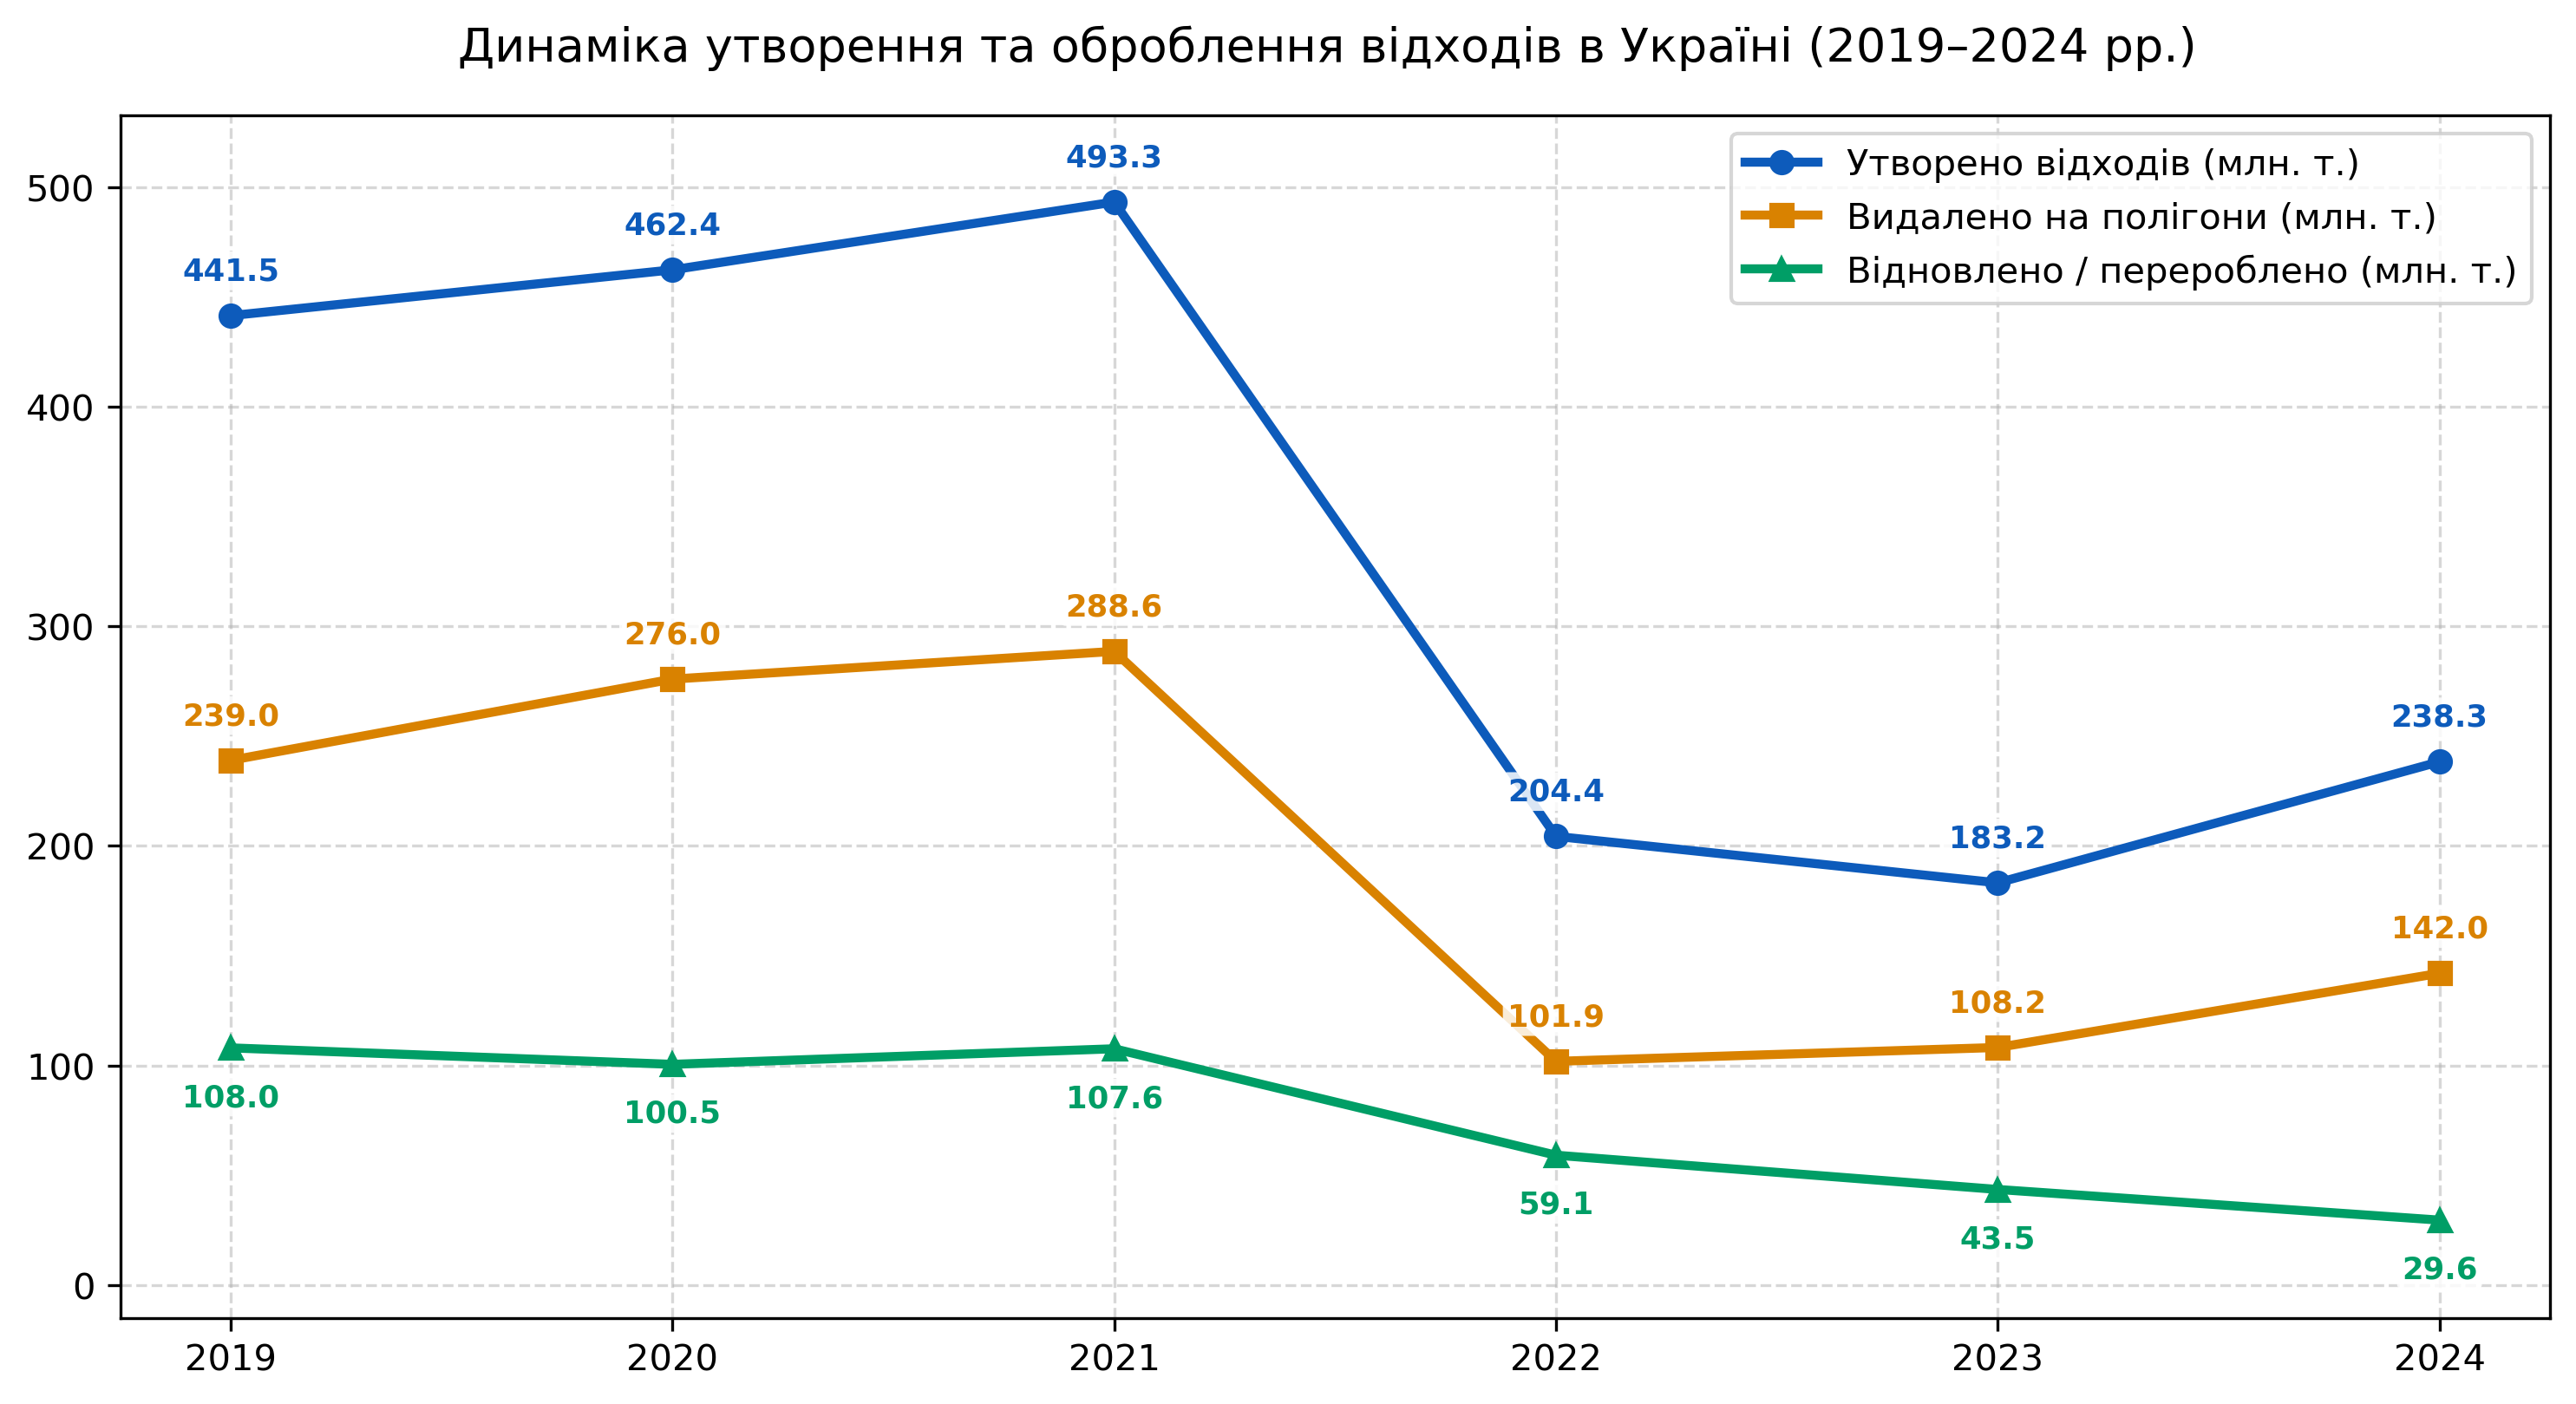

In [9]:
years = df_pivot.columns

gen = df_pivot.loc['Обсяг утворених відходів'] / 1000
landfill = df_pivot.loc['Обсяг видалених відходів на полігони'] / 1000
recovered = df_pivot.loc['Обсяг відновлених відходів'] / 1000

plt.figure(figsize=(10, 5.5), dpi=300)

plt.plot(years, gen, marker='o', linewidth=2.5, color='#0d5bbb', label='Утворено відходів (млн. т.)')
plt.plot(years, landfill, marker='s', linewidth=2.5, color='#d98200', label='Видалено на полігони (млн. т.)')
plt.plot(years, recovered, marker='^', linewidth=2.5, color='#009e66', label='Відновлено / перероблено (млн. т.)')

bbox_style = dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85)

for x, y in zip(years, gen):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0, 10), 
                 ha='center', fontsize=8.5, fontweight='bold', color='#0d5bbb',
                 bbox=bbox_style)

for x, y in zip(years, landfill):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0, 10), 
                 ha='center', fontsize=8.5, fontweight='bold', color='#d98200',
                 bbox=bbox_style)

for x, y in zip(years, recovered):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0, -16), 
                 ha='center', fontsize=8.5, fontweight='bold', color='#009e66',
                 bbox=bbox_style)

plt.title('Динаміка утворення та оброблення відходів в Україні (2019–2024 рр.) ', fontsize=13, pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.ylim(bottom=-15, top=max(gen) * 1.08)

plt.tight_layout()
plt.savefig('waste_dynamics_2019_2024.png', dpi=300)
plt.show()

In [10]:
v_rec = df_pivot.loc["Обсяг відновлених відходів"]
v_landfill = df_pivot.loc["Обсяг видалених відходів на полігони"]
v_incin = df_pivot.loc["Обсяг спалених відходів"]

v_total_processed = v_rec + v_landfill + v_incin

df_kpi = pd.DataFrame({
    'Всього оброблено відходів (тис. т)': v_total_processed,
    'Частка переробки (%)': (v_rec / v_total_processed * 100).round(2),
    'Частка захоронення (%)': (v_landfill / v_total_processed * 100).round(2),
    'Частка спалювання (%)': (v_incin / v_total_processed * 100).round(2)})

df_kpi_result = df_kpi.T

df_kpi_result

Період,2019,2020,2021,2022,2023,2024
Всього оброблено відходів (тис. т),348080.30,377517.90,397218.40,161834.70,152711.00,172522.00
Частка переробки (%),31.03,26.63,27.09,36.55,28.51,17.15
Частка захоронення (%),68.66,73.11,72.66,62.96,70.86,82.31
Частка спалювання (%),0.30,0.27,0.25,0.50,0.63,0.54


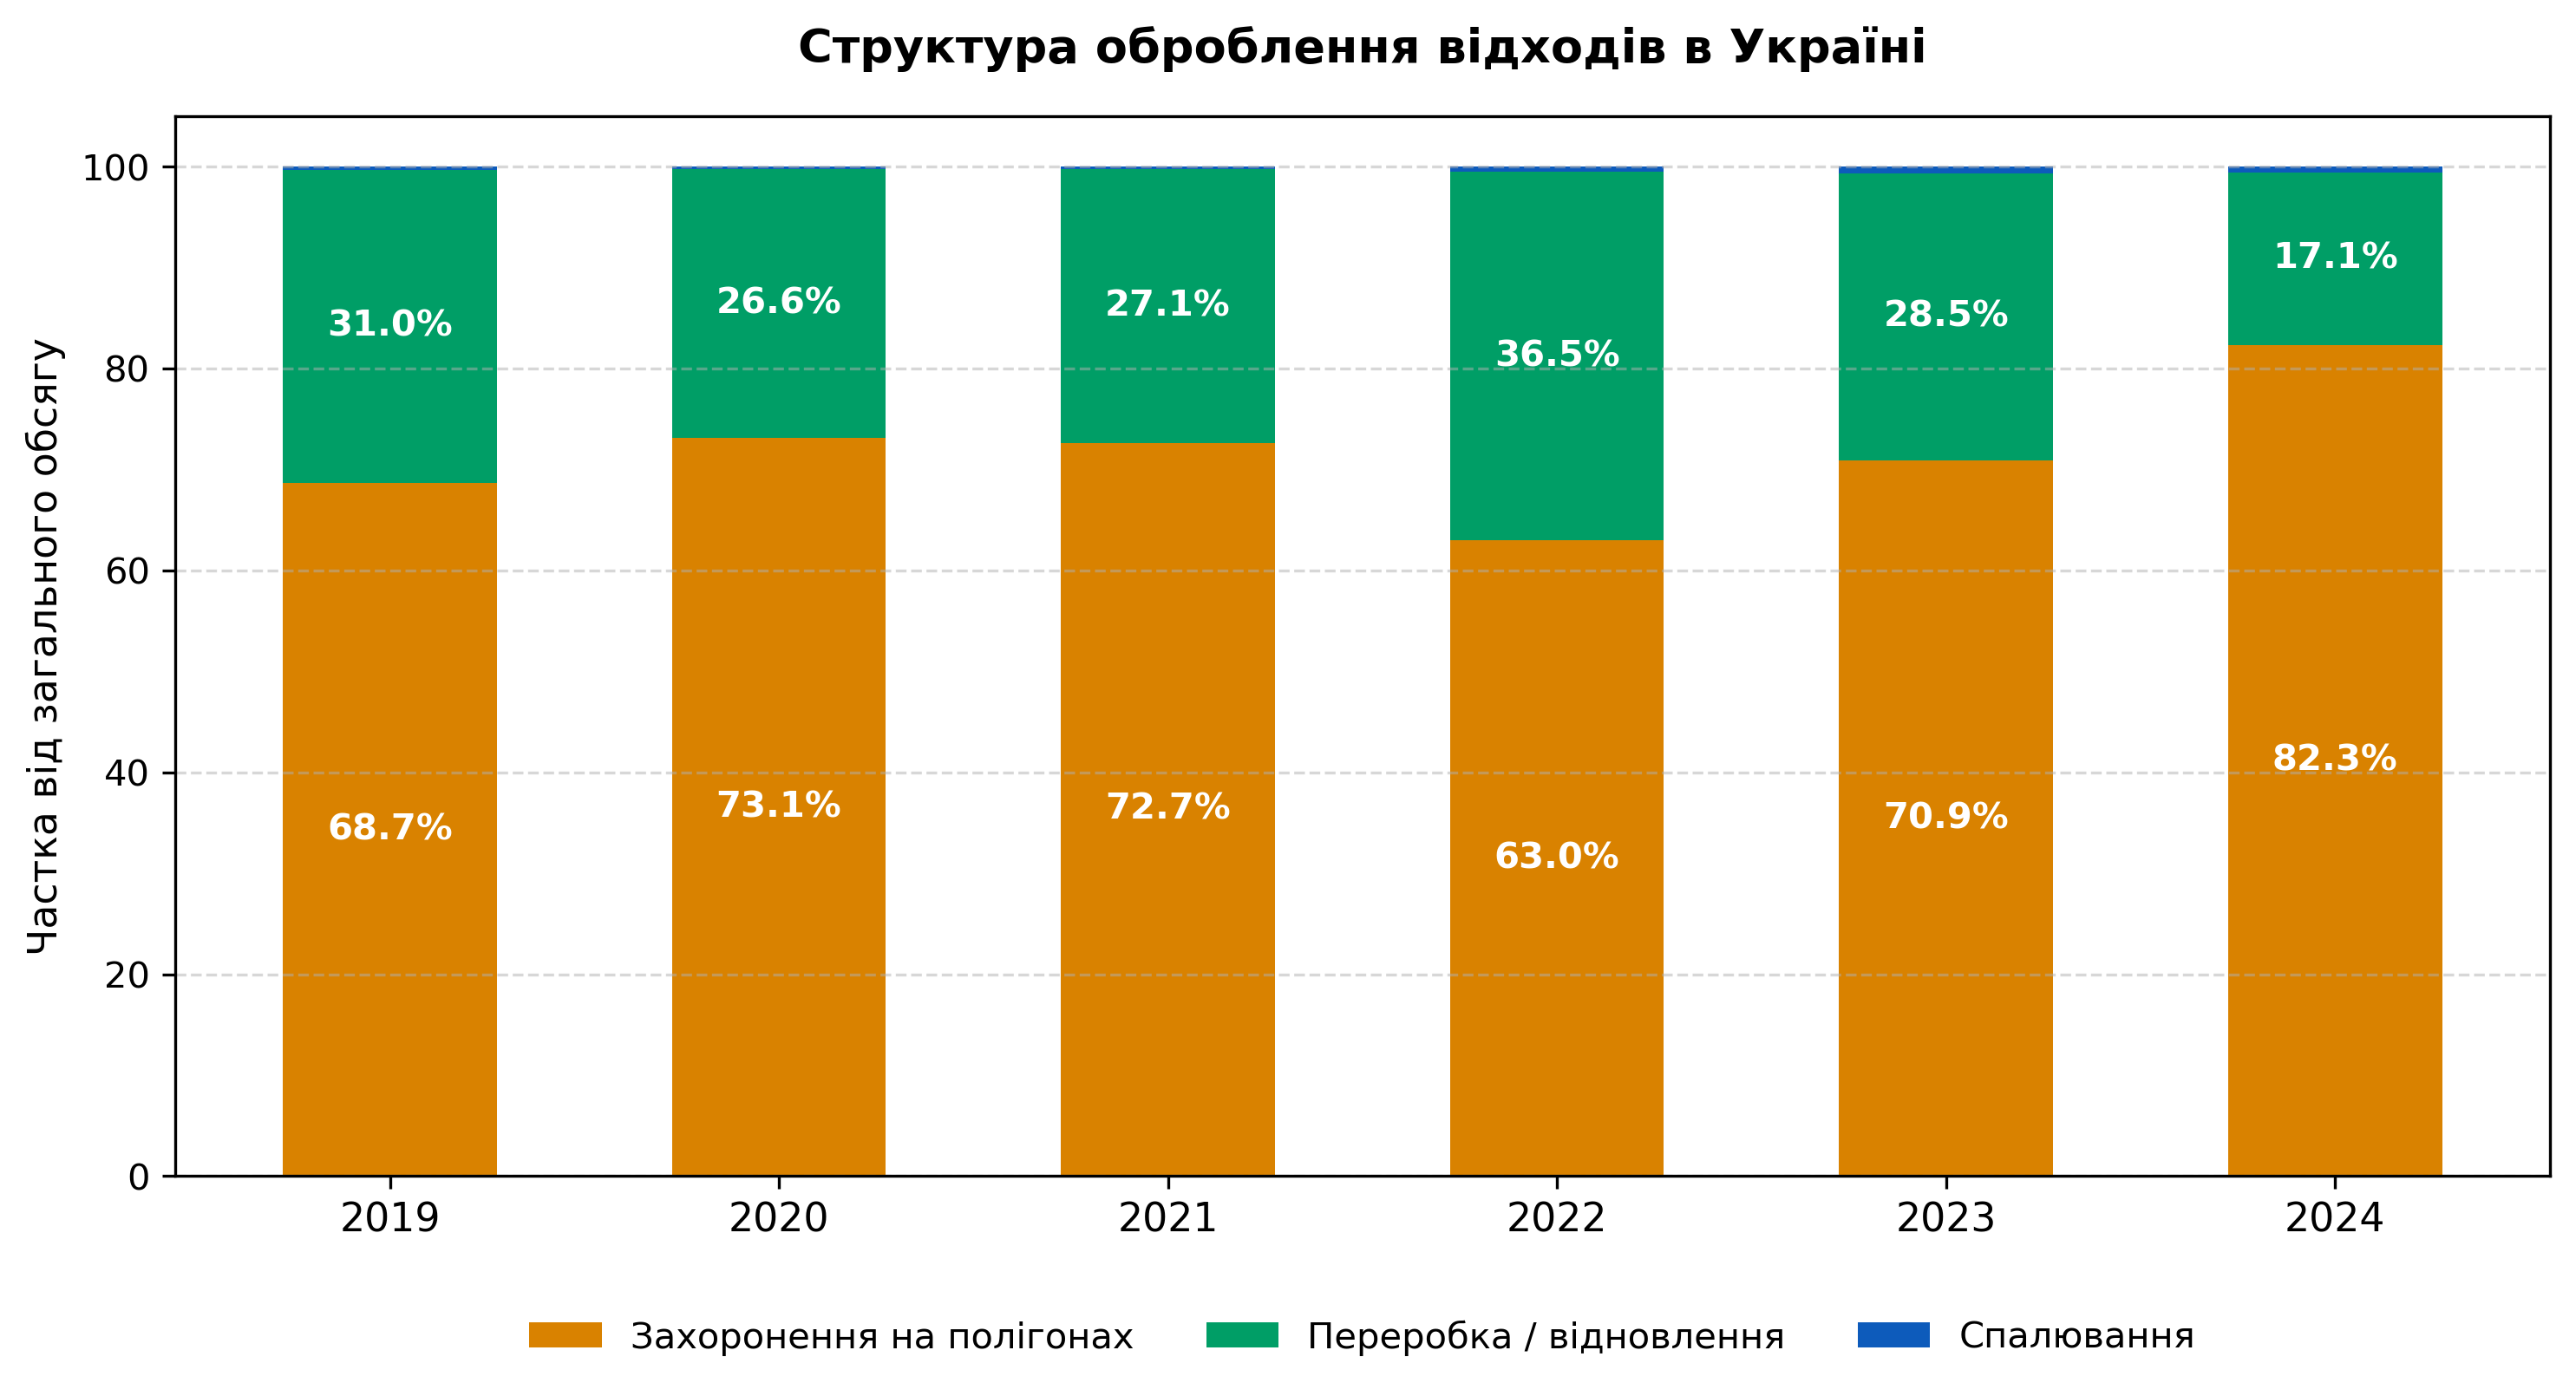

In [11]:
years = [str(col) for col in df_kpi_result.columns]

landfill = df_kpi_result.loc['Частка захоронення (%)'].values
recycling = df_kpi_result.loc['Частка переробки (%)'].values
incineration = df_kpi_result.loc['Частка спалювання (%)'].values

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

x = np.arange(len(years))
width = 0.55

c_landfill = '#d98200'  
c_recycling = '#009e66' 
c_incin = '#0d5bbb'    

p1 = ax.bar(x, landfill, width, label='Захоронення на полігонах', color=c_landfill)
p2 = ax.bar(x, recycling, width, bottom=landfill, label='Переробка / відновлення', color=c_recycling)
p3 = ax.bar(x, incineration, width, bottom=landfill + recycling, label='Спалювання', color=c_incin)

for i in range(len(years)):
    ax.text(i, landfill[i] / 2, f"{landfill[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(i, landfill[i] + recycling[i] / 2, f"{recycling[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

ax.set_title('Структура оброблення відходів в Україні', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Частка від загального обсягу', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('kpi_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
df_reg = df[(df['Період'] >= 2019) & 
    (df['Клас небезпеки відходів'] == 'I-IV. Відходи в цілому') &
    (df['Територіальний розріз'] != 'Україна')].copy()

In [13]:
piv_reg = df_reg.pivot_table(
    index=['Територіальний розріз', 'Період'],
    columns='Показник',
    values='Значення cпостереження',
    aggfunc='sum'
).reset_index()
piv_reg.head()

Показник,Територіальний розріз,Період,Обсяг видалених відходів на полігони,Обсяг відновлених відходів,"Обсяг відходів, накопичених протягом експлуатації у спеціально відведених місцях та об'єктах","Обсяг відходів, накопичених протягом експлуатації у спеціально відведених місцях та об'єктах, на одиницю площі","Обсяг відходів, накопичених протягом експлуатації у спеціально відведених місцях та об'єктах, на одну особу",Обсяг збирання відходів,Обсяг збирання відходів на одну особу,Обсяг спалених відходів,Обсяг утворених відходів,Обсяг утворених відходів від економічної діяльності підприємств за адміністративно-територіальними одиницями,Обсяг утворених відходів на одиницю площі,Обсяг утворених відходів на одну особу,"Частка відходів, видалених у спеціально відведені місця та об'єкти або спалених без отримання енергії в обсязі утворених відходів","Частка відходів, спалених та утилізованих в обсязі утворених відходів"
0,Івано-Франківська,2019,1759.6,870.2,45995.8,3302.6,33557.0,365.6,0.0,130.9,2991.7,NaN,214.8,2183.0,58.8,33.5
1,Івано-Франківська,2020,1164.2,525.3,6744.2,484.3,4942.0,406.0,298.1,50.0,1729.8,NaN,124.2,1268.0,67.4,33.3
2,Івано-Франківська,2021,253.2,499.0,NaN,NaN,NaN,NaN,NaN,49.3,790.5,NaN,NaN,NaN,NaN,NaN
3,Івано-Франківська,2022,146.5,453.0,7134.5,0.0,0.0,330.3,NaN,45.8,650.0,1514.2,0.0,0.0,NaN,NaN
4,Івано-Франківська,2023,168.6,512.0,7281.1,0.0,0.0,329.2,NaN,58.5,2519.7,NaN,0.0,0.0,NaN,NaN


In [14]:
piv_reg['Всього_оброблено'] = (
    piv_reg['Обсяг відновлених відходів'] + 
    piv_reg['Обсяг видалених відходів на полігони'] + 
    piv_reg['Обсяг спалених відходів'])

piv_reg['Частка_переробки_%'] = (piv_reg['Обсяг відновлених відходів'] / piv_reg['Всього_оброблено'] * 100).round(2)

recycling_rate_by_region = piv_reg.pivot(
    index='Територіальний розріз', 
    columns='Період', 
    values='Частка_переробки_%')

recycling_rate_by_region

Період,2019,2020,2021,2022,2023,2024
Територіальний розріз,,,,,,
Івано-Франківська,31.52,30.20,62.26,70.20,69.27,65.41
Волинська,10.16,12.02,13.32,25.66,28.28,29.89
Вінницька,27.36,35.99,23.06,23.83,27.71,20.79
Дніпропетровська,45.74,32.93,34.53,45.71,36.12,23.25
Донецька,22.25,19.66,18.39,0.07,0.06,0.01
Житомирська,16.87,11.61,11.46,9.64,1.00,1.20
Закарпатська,0.11,0.18,0.31,0.30,0.21,0.05
Запорізька,73.76,70.18,64.87,39.45,0.07,0.00
Київ,0.10,4.94,4.75,29.61,5.08,1.51


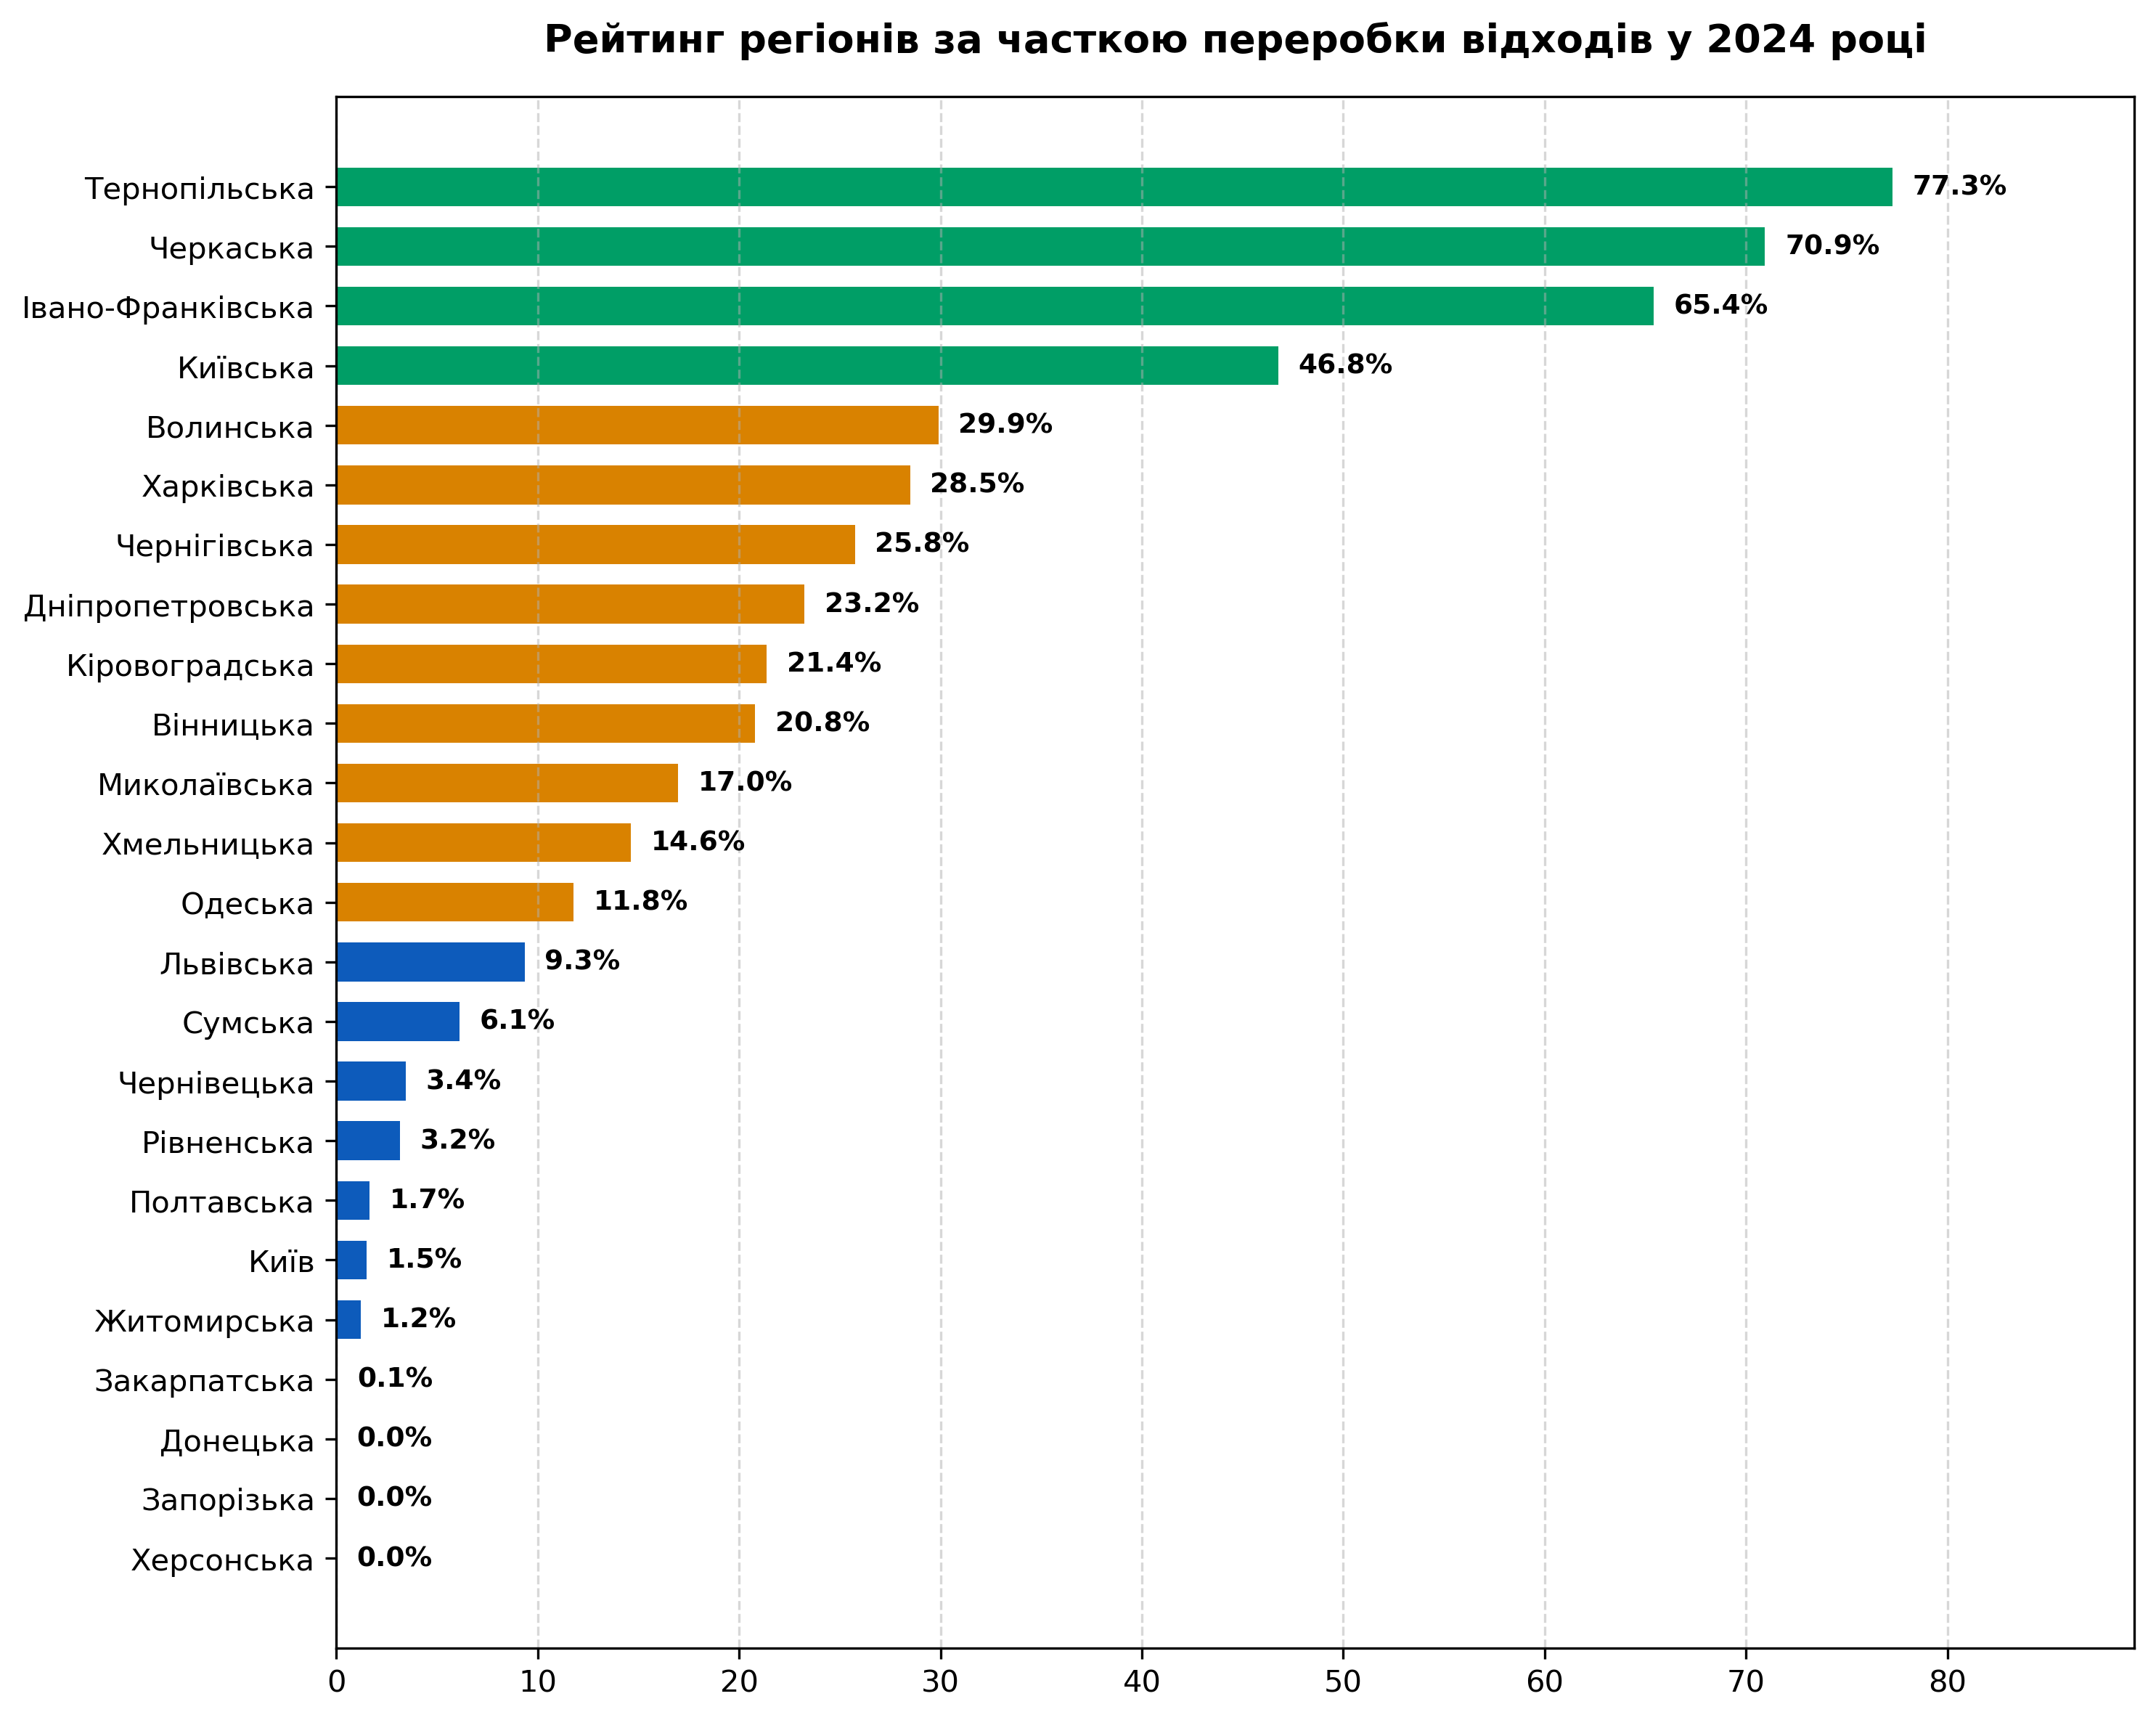

In [15]:
df_2024 = recycling_rate_by_region[2024].dropna().sort_values(ascending=True)

plt.figure(figsize=(10, 8), dpi=300)

colors = ['#009e66' if x >= 30 else '#d98200' if x >= 10 else '#0d5bbb' for x in df_2024.values]

bars = plt.barh(df_2024.index, df_2024.values, color=colors, height=0.65)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold')

plt.title('Рейтинг регіонів за часткою переробки відходів у 2024 році', fontsize=13, fontweight='bold', pad=15)
plt.xlim(0, max(df_2024.values) + 12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('region_2024_barh.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
target_indicators = [
    'Обсяг утворених відходів',
    'Обсяг відновлених відходів',
    'Обсяг спалених відходів',
    'Обсяг видалених відходів на полігони']

df_csv = df[
    (df['Період'] >= 2019) & 
    (df['Клас небезпеки відходів'] == 'I-IV. Відходи в цілому') &
    (df['Показник'].isin(target_indicators))].copy()

In [17]:
df_csv.to_csv('filtered_waste_data.csv', index=False, encoding='utf-8')